# imports

In [1]:
import os
import random
import string
import json
from collections import Counter, defaultdict
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import vit_b_16, ViT_B_16_Weights
import matplotlib.pyplot as plt

In [2]:
# reproducibility
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)

device: cuda


# data preprocessing

In [3]:
coco_path = '/kaggle/input/coco-2017-dataset/coco2017'
images_path = os.path.join(coco_path, "")
annotations_path = os.path.join(coco_path, 'annotations')
train_images_path = os.path.join(images_path, 'train2017')
val_images_path = os.path.join(images_path, 'val2017')
test_images_path = os.path.join(images_path, 'test2017')
train_annotations_file = os.path.join(annotations_path, 'captions_train2017.json')
val_annotations_file = os.path.join(annotations_path, 'captions_val2017.json')

In [4]:
def load_captions(annotations_file):
    with open(annotations_file, "r") as f:
        annotations = json.load(f)
    captions = defaultdict(list)
    for ann in annotations["annotations"]:
        image_id = ann["image_id"]
        caption = ann["caption"]
        image_file = f"{image_id:012d}.jpg"
        captions[image_file].append(caption)
    return captions

train_captions = load_captions(train_annotations_file)
val_captions   = load_captions(val_annotations_file)

In [5]:
print("num train images:", len(train_captions))
print("num val images:", len(val_captions))

num train images: 118287
num val images: 5000


In [6]:
# cleaning captions
def clean_caption(caption):
    caption = caption.lower()
    caption = caption.translate(str.maketrans("", "", string.punctuation))
    caption = " ".join(caption.split())
    return caption

for image in train_captions:
    train_captions[image] = [clean_caption(c) for c in train_captions[image]]

for image in val_captions:
    val_captions[image] = [clean_caption(c) for c in val_captions[image]]

In [7]:
# data augmentation funcs
train_transform = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BICUBIC),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def load_image(image_file, transform):
    img = Image.open(image_file).convert("RGB")
    return transform(img)

In [8]:
# dictionary tokenizer
word_counter = Counter()
for _, caption_list in train_captions.items():
    for caption in caption_list:
        word_counter.update(caption.split())

vocab_threshold = 5
vocab = [w for w, c in word_counter.items() if c >= vocab_threshold]

stoi = {w: i + 4 for i, w in enumerate(vocab)}
stoi["<PAD>"] = 0
stoi["<START>"] = 1
stoi["<END>"] = 2
stoi["<UNK>"] = 3

itos = {i: w for w, i in stoi.items()}
vocab_size = len(stoi)

In [9]:
print("vocab_size:", vocab_size)

vocab_size: 10307


In [10]:
def encode_caption(caption):
    tokens = caption.split()
    ids = [stoi["<START>"]] + [stoi.get(t, stoi["<UNK>"]) for t in tokens] + [stoi["<END>"]]
    return ids

def decode_caption(ids):
    return " ".join(itos.get(i, "<UNK>") for i in ids)

def pad_caption(ids, max_length):
    # pads or truncates to exactly max_length
    if len(ids) >= max_length:
        return ids[:max_length]
    return ids + [stoi["<PAD>"]] * (max_length - len(ids))


In [11]:
# choose a reasonable max length
raw_max = max(len(c.split()) for caps in train_captions.values() for c in caps) + 2
max_length = min(raw_max, 40)  # cap to keep compute
print("max_length:", max_length)

max_length: 40


In [12]:
def create_sequences(encoded_caption):
    # input - all but last
    # target - all but first
    return encoded_caption[:-1], encoded_caption[1:]

In [13]:
encoded_train_inputs = defaultdict(list)
encoded_train_targets = defaultdict(list)
encoded_val_inputs = defaultdict(list)
encoded_val_targets = defaultdict(list)

for image_key, caps in train_captions.items():
    for cap in caps:
        ids = pad_caption(encode_caption(cap), max_length)
        inp, tgt = create_sequences(ids)
        encoded_train_inputs[image_key].append(inp)
        encoded_train_targets[image_key].append(tgt)

for image_key, caps in val_captions.items():
    for cap in caps:
        ids = pad_caption(encode_caption(cap), max_length)
        inp, tgt = create_sequences(ids)
        encoded_val_inputs[image_key].append(inp)
        encoded_val_targets[image_key].append(tgt)

In [14]:
time_steps = max_length - 1
print("time_steps:", time_steps)

time_steps: 39


In [15]:
class CocoCaptionPairsDataset(Dataset):
    def __init__(self, captions_dict, input_dict, target_dict, images_path, transform):
        super().__init__()
        self.captions_dict = captions_dict
        self.input_dict = input_dict
        self.target_dict = target_dict
        self.images_path = images_path
        self.transform = transform

        # build (image_key, caption_idx) pairs so we use all captions
        self.pairs = []
        for image_key, caps in captions_dict.items():
            for j in range(len(caps)):
                self.pairs.append((image_key, j))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        image_key, cap_idx = self.pairs[idx]
        img_path = os.path.join(self.images_path, image_key)

        img = load_image(img_path, self.transform)  # (3, 224, 224)

        cap_in = torch.tensor(self.input_dict[image_key][cap_idx], dtype=torch.long)   # (t,)
        cap_tgt = torch.tensor(self.target_dict[image_key][cap_idx], dtype=torch.long) # (t,)

        return img, cap_in, cap_tgt


def make_loader(dataset, batch_size, shuffle, num_workers=4, pin_memory=True):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=True,   # keeps batch size consistent (nice for speed/stability)
        persistent_workers=(num_workers > 0)
    )


# create datasets/loaders (use your dict names from the vit version)
train_dataset = CocoCaptionPairsDataset(
    train_captions, encoded_train_inputs, encoded_train_targets,
    train_images_path, train_transform
)
val_dataset = CocoCaptionPairsDataset(
    val_captions, encoded_val_inputs, encoded_val_targets,
    val_images_path, val_transform
)

# BATCH SIZE
BATCH_SIZE = 128

# choose num_workers based on kaggle/p100; 2-4 is usually safe
train_loader = make_loader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = make_loader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

num train pairs: 591753
num val pairs: 25014


In [ ]:
print("train pairs:", len(train_dataset), "val pairs:", len(val_dataset))

training example:


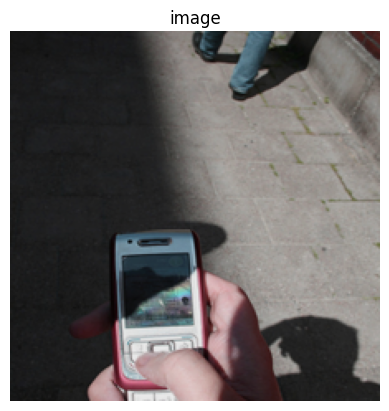

input caption:  <START> this person is holding a cell phone while standing on the sidewalk <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
target caption: this person is holding a cell phone while standing on the sidewalk <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
validation example:


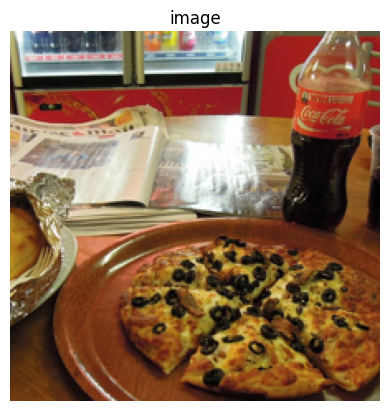

input caption:  <START> a pizza sitting on top of a plate next to a foil bag of food <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
target caption: a pizza sitting on top of a plate next to a foil bag of food <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>


In [16]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(3,1,1)


def denormalize(img_tensor):
    # img_tensor: (3, h, w) normalized
    # returns float tensor in [0, 1] (clipped)
    x = img_tensor.detach().cpu()
    x = x * IMAGENET_STD + IMAGENET_MEAN
    return x.clamp(0.0, 1.0)

def visualize_example(caption_dict, input_seq_dict, target_seq_dict, transform, path):
    # shows a random (image, caption) pair
    random_image = random.choice(list(caption_dict.keys()))
    caption_idx = random.randint(0, len(caption_dict[random_image]) - 1)

    image_path = os.path.join(path, random_image)
    image_tensor = load_image(image_path, transform)

    # fix: denormalize so matplotlib shows correct colors
    image_vis = denormalize(image_tensor)
    image_array = image_vis.permute(1, 2, 0).numpy()

    input_caption_encoded = input_seq_dict[random_image][caption_idx]
    target_caption_encoded = target_seq_dict[random_image][caption_idx]

    input_caption = decode_caption(input_caption_encoded)
    target_caption = decode_caption(target_caption_encoded)

    plt.imshow(image_array)
    plt.axis("off")
    plt.title("image")
    plt.show()

    print(f"input caption:  {input_caption}")
    print(f"target caption: {target_caption}")

print("training example:")
visualize_example(train_captions, encoded_train_inputs, encoded_train_targets, train_transform, train_images_path)

print("validation example:")
visualize_example(val_captions, encoded_val_inputs, encoded_val_targets, val_transform, val_images_path)

# architecture

In [20]:
class ViTTokenEncoder(nn.Module):
    def __init__(self, freeze=True):
        super().__init__()

        # pretrained vit-b/16
        weights = ViT_B_16_Weights.IMAGENET1K_V1
        self.vit = vit_b_16(weights=weights)

        # remove classification head usage; we will use encoder outputs
        # we will call internal steps to get tokens: (b, s, 768)
        if freeze:
            for p in self.vit.parameters():
                p.requires_grad = False

        self.hidden_dim = self.vit.hidden_dim  # 768 for vit-b/16

    def forward(self, x):
        # returns tokens including cls token: (b, s, d)
        # this mirrors torchvision's vit forward, but stops before heads.
        n = x.shape[0]
        x = self.vit._process_input(x)  # (b, num_patches, d)

        # add cls token
        cls_token = self.vit.class_token.expand(n, -1, -1)  # (b, 1, d)
        x = torch.cat((cls_token, x), dim=1)                # (b, 1+num_patches, d)

        # add position embedding
        x = x + self.vit.encoder.pos_embedding
        x = self.vit.encoder.dropout(x)

        # transformer encoder
        x = self.vit.encoder.layers(x)
        x = self.vit.encoder.ln(x)
        return x  # (b, s, d)

In [22]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        # classic sin/cos encoding
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        pe = pe.unsqueeze(1)  # (max_len, 1, d_model)

        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (t, b, d)
        t = x.size(0)
        return x + self.pe[:t]

In [23]:
def causal_mask(t, device):
    # (t, t) with -inf above diagonal for causal attention
    m = torch.triu(torch.ones(t, t, device=device), diagonal=1).bool()
    out = torch.zeros(t, t, device=device)
    out[m] = float("-inf")
    return out

class Captioner(nn.Module):
    def __init__(
        self,
        vocab_size,
        pad_id,
        d_model=512,
        nhead=8,
        num_decoder_layers=4,
        dim_feedforward=2048,
        dropout=0.1,
        freeze_vit=True
    ):
        super().__init__()

        # encoder
        self.encoder = ViTTokenEncoder(freeze=freeze_vit)
        enc_dim = self.encoder.hidden_dim  # 768

        # project vit tokens -> decoder dimension
        self.enc_proj = nn.Linear(enc_dim, d_model)

        # text embedding
        self.pad_id = pad_id
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional = PositionalEncoding(d_model, max_len=512)
        self.emb_dropout = nn.Dropout(dropout)

        # transformer decoder (cross-attn uses memory)
        layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=False,  # we will use (t, b, d)
            norm_first=True
        )
        self.decoder = nn.TransformerDecoder(layer, num_layers=num_decoder_layers)

        # output head
        self.fc_out = nn.Linear(d_model, vocab_size)

        # weight tying (simple accuracy + parameter win)
        self.fc_out.weight = self.embedding.weight

    def forward(self, images, captions_in):
        """
        images: (b, 3, 224, 224)
        captions_in: (b, t) token ids, does not include the final target shift
        returns: logits (b, t, vocab)
        """
        b, t = captions_in.shape

        # encode image -> tokens
        mem = self.encoder(images)             # (b, s, 768)
        mem = self.enc_proj(mem)               # (b, s, d)
        mem = mem.transpose(0, 1).contiguous() # (s, b, d)

        # embed text
        tgt = self.embedding(captions_in)      # (b, t, d)
        tgt = tgt.transpose(0, 1).contiguous() # (t, b, d)
        tgt = self.positional(tgt)
        tgt = self.emb_dropout(tgt)

        # masks
        tgt_mask = causal_mask(t, device=tgt.device)  # (t, t)
        tgt_key_padding = (captions_in == self.pad_id)  # (b, t)

        # decode
        out = self.decoder(
            tgt=tgt,
            memory=mem,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding
        )  # (t, b, d)

        out = out.transpose(0, 1).contiguous()        # (b, t, d)
        logits = self.fc_out(out)                      # (b, t, vocab)
        return logits

# model initalization

In [24]:
pad_id = stoi["<PAD>"]
# note: vit-b/16 has ~86m params, but we freeze it by default
# trainable params are mostly the decoder (so it is feasible on limited hardware)
model = Captioner(
    vocab_size=vocab_size,
    pad_id=pad_id,
    d_model=512,
    nhead=8,
    num_decoder_layers=4,
    dim_feedforward=2048,
    dropout=0.1,
    freeze_vit=True
).to(device)

learning_rate = 2e-4
weight_decay = 1e-4
nepochs = 10
batch_size = 128
max_grad_norm = 1.0

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=nepochs, eta_min=0)

# important fix - ignore pad
loss_fn = nn.CrossEntropyLoss(ignore_index=pad_id)

training_loss = []
val_loss = []

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:01<00:00, 203MB/s]  


In [25]:
# quick param count helpers
def count_params(m):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_params(model)
print("total params:", total_params, "(", total_params//1_000_000, "m )")
print("trainable params:", trainable_params, "(", trainable_params//1_000_000, "m )")

total params: 109065003 ( 109 m )
trainable params: 22497347 ( 22 m )


In [26]:
def calculate_average_val_loss(model, val_loader, loss_fn):
    model.eval()
    total = 0.0
    nb = 0

    with torch.no_grad():
        for imgs, cap_in, cap_tgt in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            cap_in = cap_in.to(device, non_blocking=True)
            cap_tgt = cap_tgt.to(device, non_blocking=True)

            logits = model(imgs, cap_in)  # (b, t, v)
            loss = loss_fn(logits.reshape(-1, vocab_size), cap_tgt.reshape(-1))

            total += loss.item()
            nb += 1

    return total / max(nb, 1)


In [29]:
# cell: TRAINING (dataloader + checkpointing)
# keep constants up top as you requested

# ----------------
# constants
# ----------------
nepochs = 10
batch_size = 128
max_grad_norm = 1.0
print_interval = 2

NUM_WORKERS = 4
PIN_MEMORY = True

SAVE_DIR = "."  # change if you want
RUN_BASENAME = "vit_transformer_coco_captioner"
DATE = date_stamp()

RESUME_CKPT_PATH = None
# example:
# RESUME_CKPT_PATH = "./vit_transformer_coco_captioner_2026-01-07_last.ckpt"

# ----------------
# (re)build loaders if batch_size changed
# ----------------
train_loader = make_loader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = make_loader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

# ----------------
# checkpoint file names (date included)
# ----------------
ckpt_last_path = os.path.join(SAVE_DIR, f"{RUN_BASENAME}_{DATE}_last.ckpt")
ckpt_best_path = os.path.join(SAVE_DIR, f"{RUN_BASENAME}_{DATE}_best.ckpt")
weights_path   = os.path.join(SAVE_DIR, f"{RUN_BASENAME}_{DATE}.pth")  # state_dict only (inference convenience)

# ----------------
# config saved into checkpoint for inference/reconstruction
# ----------------
config = {
    "vocab_size": vocab_size,
    "pad_id": stoi["<PAD>"],
    "max_length": max_length,
    "time_steps": time_steps,

    # model hyperparams (match your model constructor)
    "d_model": 512,
    "nhead": 8,
    "num_decoder_layers": 4,
    "dim_feedforward": 2048,
    "dropout": 0.1,
    "freeze_vit": True,
}

# ----------------
# optional resume
# ----------------
start_epoch = 0
best_val = float("inf")

if RESUME_CKPT_PATH is not None and os.path.exists(RESUME_CKPT_PATH):
    ckpt = load_checkpoint(RESUME_CKPT_PATH, model, optimizer=optimizer, scheduler=lr_scheduler, map_location=device)
    start_epoch = ckpt["epoch"] + 1
    training_loss = ckpt.get("training_loss", [])
    val_loss = ckpt.get("val_loss", [])
    best_val = ckpt.get("best_val", best_val)

    print("resumed from:", RESUME_CKPT_PATH)
    print("start_epoch:", start_epoch, "best_val:", best_val)

# ----------------
# TRAINING
# ----------------
for epoch in range(start_epoch, nepochs):
    print("\ntraining epoch", epoch + 1, "/", nepochs)

    model.train()

    epoch_total = 0.0
    nb = 0

    interval_total = 0.0
    interval_nb = 0

    for b, (imgs, cap_in, cap_tgt) in enumerate(train_loader):
        imgs = imgs.to(device, non_blocking=True)
        cap_in = cap_in.to(device, non_blocking=True)
        cap_tgt = cap_tgt.to(device, non_blocking=True)

        logits = model(imgs, cap_in)  # (b, t, v)
        loss = loss_fn(logits.reshape(-1, vocab_size), cap_tgt.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        epoch_total += loss.item()
        nb += 1

        interval_total += loss.item()
        interval_nb += 1

        if interval_nb == print_interval:
            print(" batch", b + 1, "/", len(train_loader), "avg interval loss:", interval_total / interval_nb)
            interval_total = 0.0
            interval_nb = 0

    avg_train = epoch_total / max(nb, 1)
    training_loss.append(avg_train)

    print("evaluating...")
    avg_val = calculate_average_val_loss(model, val_loader, loss_fn)
    val_loss.append(avg_val)

    print("avg train loss:", avg_train, "| avg val loss:", avg_val)
    lr_scheduler.step()

    # save "last" checkpoint every epoch (resume training)
    save_checkpoint(
        ckpt_last_path,
        model=model,
        optimizer=optimizer,
        scheduler=lr_scheduler,
        epoch=epoch,
        training_loss=training_loss,
        val_loss=val_loss,
        config=config,
        stoi=stoi,
        itos=itos,
        best_val=best_val
    )

    # also save a lightweight inference file (state_dict only)
    torch.save(model.state_dict(), weights_path)

    # save best checkpoint (based on val)
    if avg_val < best_val:
        best_val = avg_val
        save_checkpoint(
            ckpt_best_path,
            model=model,
            optimizer=optimizer,
            scheduler=lr_scheduler,
            epoch=epoch,
            training_loss=training_loss,
            val_loss=val_loss,
            config=config,
            stoi=stoi,
            itos=itos,
            best_val=best_val
        )

    print("saved last:", ckpt_last_path)
    print("saved weights:", weights_path)
    print("best val:", best_val, "| best ckpt:", ckpt_best_path)



training epoch 1 / 10
 batch 2 / 4623 avg interval loss: 129.7521858215332
 batch 4 / 4623 avg interval loss: 121.55779266357422
 batch 6 / 4623 avg interval loss: 116.38331985473633
 batch 8 / 4623 avg interval loss: 119.55215072631836
 batch 10 / 4623 avg interval loss: 110.2621078491211
 batch 12 / 4623 avg interval loss: 103.41987609863281


KeyboardInterrupt: 

In [ ]:
from datetime import datetime

def date_stamp():
    return datetime.now().strftime("%Y-%m-%d")

In [ ]:
def save_checkpoint(
    path_ckpt,
    model,
    optimizer,
    scheduler,
    epoch,
    training_loss,
    val_loss,
    config,
    stoi,
    itos,
    best_val=None
):
    ckpt = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "training_loss": training_loss,
        "val_loss": val_loss,
        "best_val": best_val,

        # save everything needed to reconstruct for inference
        "config": config,
        "stoi": stoi,
        "itos": itos,

        # rng states for exact resume reproducibility
        "rng_torch": torch.get_rng_state(),
        "rng_cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        "rng_python": random.getstate(),
        "rng_numpy": np.random.get_state(),
    }
    torch.save(ckpt, path_ckpt)

def load_checkpoint(path_ckpt, model, optimizer=None, scheduler=None, map_location=None, strict=True):
    ckpt = torch.load(path_ckpt, map_location=map_location)

    model.load_state_dict(ckpt["model_state_dict"], strict=strict)

    if optimizer is not None and ckpt.get("optimizer_state_dict") is not None:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    if scheduler is not None and ckpt.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])

    # restore rng states if present
    if "rng_torch" in ckpt and ckpt["rng_torch"] is not None:
        torch.set_rng_state(ckpt["rng_torch"])
    if torch.cuda.is_available() and ckpt.get("rng_cuda") is not None:
        torch.cuda.set_rng_state_all(ckpt["rng_cuda"])
    if "rng_python" in ckpt and ckpt["rng_python"] is not None:
        random.setstate(ckpt["rng_python"])
    if "rng_numpy" in ckpt and ckpt["rng_numpy"] is not None:
        np.random.set_state(ckpt["rng_numpy"])

    return ckpt

----
----
----
----
----
Random Image: 000000234779.jpg


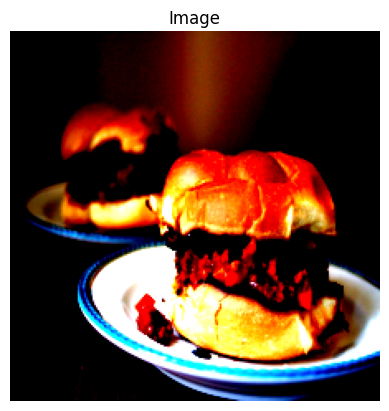

Original Caption: <START> two sloppy joe sandwiches on two separate plates <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Generated Caption: sandwich eggs fries potatoes ketchup strawberries and butter <END>
BLEU-1 Score: 0.0015
BLEU-4 Score: 0.0003
Generated Caption: burger is kept on bun <END>
BLEU-1 Score: 0.0003
BLEU-4 Score: 0.0000
Generated Caption: sandwich with pickles and lettuce on it <END>
BLEU-1 Score: 0.0017
BLEU-4 Score: 0.0002
Generated Caption: sandwich on plate <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Generated Caption: breakfast breakfast sandwich with bacon kiwi bread syrup butter sprouts tips spear <END>
BLEU-1 Score: 0.0052
BLEU-4 Score: 0.0011
Random Image: 000000170955.jpg


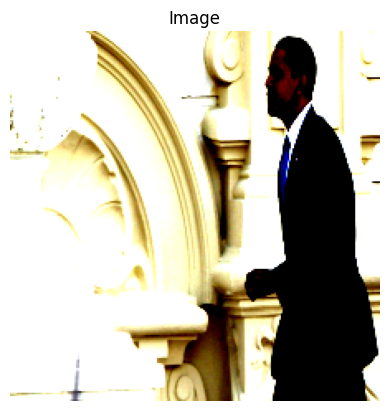

Original Caption: <START> president barack obama walking near white building <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Generated Caption: bride sitting in bathroom <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Generated Caption: woman posing for photo <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Generated Caption: man with polka dot tie <END>
BLEU-1 Score: 0.0002
BLEU-4 Score: 0.0000
Generated Caption: wedding woman standing together <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Generated Caption: bath tub in bathroom <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Random Image: 000000344100.jpg


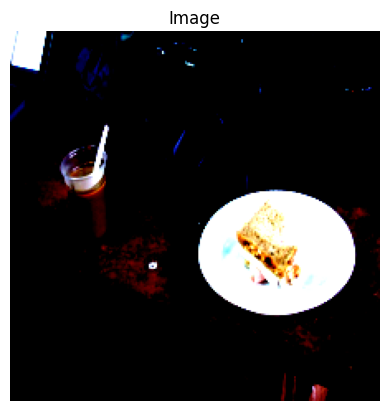

Original Caption: <START> table has camera cup and plate with sandwich on it <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Generated Caption: sandwich served into cafeteria bread <END>
BLEU-1 Score: 0.0003
BLEU-4 Score: 0.0000
Generated Caption: steak cook meal arranged in blender <END>
BLEU-1 Score: 0.0004
BLEU-4 Score: 0.0001
Generated Caption: some desserts sitting around table <END>
BLEU-1 Score: 0.0003
BLEU-4 Score: 0.0000
Generated Caption: decorated cake displayed in restaurant kitchen <END>
BLEU-1 Score: 0.0004
BLEU-4 Score: 0.0001
Generated Caption: some pizzas on table <END>
BLEU-1 Score: 0.0001
BLEU-4 Score: 0.0000
Random Image: 000000118921.jpg


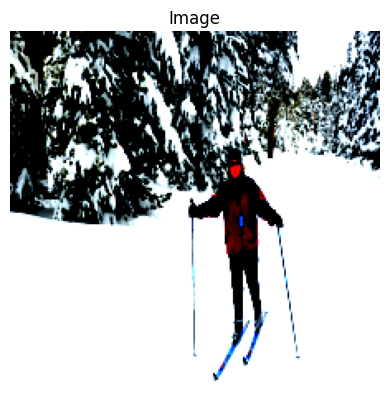

Original Caption: <START> woman is wearing pink and black jacket is sking <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Generated Caption: woman posing in the snow <END>
BLEU-1 Score: 0.0003
BLEU-4 Score: 0.0000
Generated Caption: person skiing down hill <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Generated Caption: group of skiers trekking through the woods <END>
BLEU-1 Score: 0.0008
BLEU-4 Score: 0.0002
Generated Caption: guy skiing down hill <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Generated Caption: person skiing down hill <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Random Image: 000000574810.jpg


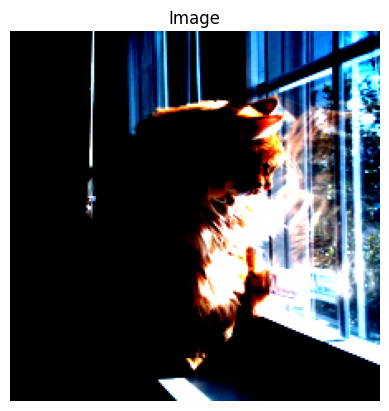

Original Caption: <START> an orange cat perched in window watching outside <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
Generated Caption: cat stares into fridge <END>
BLEU-1 Score: 0.0001
BLEU-4 Score: 0.0000
Generated Caption: cat sitting inside of suitcase <END>
BLEU-1 Score: 0.0003
BLEU-4 Score: 0.0000
Generated Caption: cat inside suitcase <END>
BLEU-1 Score: 0.0000
BLEU-4 Score: 0.0000
Generated Caption: cat lying on chair <END>
BLEU-1 Score: 0.0001
BLEU-4 Score: 0.0000
Generated Caption: cat sitting inside of suitcase <END>
BLEU-1 Score: 0.0003
BLEU-4 Score: 0.0000


In [25]:
# cell 15: decoding (greedy, top-p, beam) - minimal but correct
# note: these decode by re-running the model each step (slow but simple and learning-friendly)

def greedy_decode(model, image_tensor, max_len=30):
    model.eval()
    with torch.no_grad():
        img = image_tensor.unsqueeze(0).to(device)

        tokens = [stoi["<START>"]]
        for _ in range(max_len):
            cap_in = torch.tensor([tokens + [pad_id] * (time_steps - len(tokens) + 1)], device=device)[:, :time_steps]
            # cap_in shape: (1, t)

            logits = model(img, cap_in)  # (1, t, v)
            step = len(tokens) - 1
            next_id = torch.argmax(logits[0, step], dim=-1).item()

            if next_id == stoi["<END>"] or next_id == pad_id:
                break
            tokens.append(next_id)

        words = [itos.get(i, "<UNK>") for i in tokens[1:]]
        return words

def top_p_decode(model, image_tensor, max_len=30, top_p=0.9, temperature=1.0):
    model.eval()
    with torch.no_grad():
        img = image_tensor.unsqueeze(0).to(device)

        tokens = [stoi["<START>"]]
        for _ in range(max_len):
            cap_in = torch.tensor([tokens + [pad_id] * (time_steps - len(tokens) + 1)], device=device)[:, :time_steps]

            logits = model(img, cap_in)  # (1, t, v)
            step = len(tokens) - 1
            logit = logits[0, step] / max(temperature, 1e-6)
            probs = F.softmax(logit, dim=-1)

            sorted_probs, sorted_idx = torch.sort(probs, descending=True)
            cumsum = torch.cumsum(sorted_probs, dim=0)
            cutoff = torch.searchsorted(cumsum, top_p)

            keep = sorted_idx[:cutoff + 1]
            keep_probs = probs[keep]
            keep_probs = keep_probs / keep_probs.sum()

            next_id = keep[torch.multinomial(keep_probs, 1)].item()
            if next_id == stoi["<END>"] or next_id == pad_id:
                break
            tokens.append(next_id)

        words = [itos.get(i, "<UNK>") for i in tokens[1:]]
        return words

def beam_decode(model, image_tensor, max_len=30, beam_size=5, alpha=0.7, block_trigrams=True):
    model.eval()
    with torch.no_grad():
        img = image_tensor.unsqueeze(0).to(device)

        start_id = stoi["<START>"]
        end_id = stoi["<END>"]

        beams = [([start_id], 0.0)]
        completed = []

        for _ in range(max_len):
            new_beams = []

            for tokens, logp in beams:
                if tokens[-1] == end_id:
                    completed.append((tokens, logp))
                    continue

                # prepare padded caption input (1, t)
                cap_in = torch.tensor([tokens + [pad_id] * (time_steps - len(tokens) + 1)], device=device)[:, :time_steps]
                logits = model(img, cap_in)  # (1, t, v)
                step = len(tokens) - 1

                lp = F.log_softmax(logits[0, step], dim=-1)  # (v,)

                # trigram blocking (helps reduce repetitions)
                if block_trigrams and len(tokens) >= 3:
                    trigrams = set()
                    for i in range(len(tokens) - 2):
                        trigrams.add((tokens[i], tokens[i+1], tokens[i+2]))

                    prev2 = (tokens[-2], tokens[-1])
                    for v in range(vocab_size):
                        if (prev2[0], prev2[1], v) in trigrams:
                            lp[v] = -1e9

                topk_lp, topk_idx = torch.topk(lp, beam_size)
                for k in range(beam_size):
                    nxt = topk_idx[k].item()
                    new_beams.append((tokens + [nxt], logp + topk_lp[k].item()))

            if not new_beams:
                break

            # length normalization
            def norm_score(item):
                toks, lpv = item
                L = max(1, len(toks) - 1)
                return lpv / (L ** alpha)

            new_beams.sort(key=norm_score, reverse=True)
            beams = new_beams[:beam_size]

        completed.extend([b for b in beams if b[0][-1] == end_id])
        if completed:
            best_tokens, best_logp = max(completed, key=lambda x: x[1] / (max(1, len(x[0]) - 1) ** alpha))
        else:
            best_tokens, best_logp = max(beams, key=lambda x: x[1] / (max(1, len(x[0]) - 1) ** alpha))

        # decode (skip start and stop at end)
        out = []
        for i in best_tokens[1:]:
            if i == end_id or i == pad_id:
                break
            out.append(itos.get(i, "<UNK>"))
        return out


In [6]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def visualize_and_sample(num_samples=5, decode_mode="beam"):
    smoothing = SmoothingFunction().method1

    keys = list(val_captions.keys())
    for _ in range(num_samples):
        image_key = random.choice(keys)
        img_path = os.path.join(val_images_path, image_key)

        img_t = load_image(img_path, val_transform)
        img_np = img_t.permute(1, 2, 0).cpu().numpy()

        plt.imshow(img_np)
        plt.axis("off")
        plt.title(image_key)
        plt.show()

        # pick one reference for quick bleu, but print all refs for sanity
        refs = [c.split() for c in val_captions[image_key]]
        print("references:")
        for r in refs:
            print(" -", " ".join(r))

        if decode_mode == "greedy":
            gen = greedy_decode(model, img_t, max_len=30)
        elif decode_mode == "top_p":
            gen = top_p_decode(model, img_t, max_len=30, top_p=0.9, temperature=1.0)
        else:
            gen = beam_decode(model, img_t, max_len=30, beam_size=5, alpha=0.7, block_trigrams=True)

        print("\ngenerated:", " ".join(gen))

        bleu1 = sentence_bleu(refs, gen, weights=(1,0,0,0), smoothing_function=smoothing)
        bleu4 = sentence_bleu(refs, gen, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoothing)
        print("bleu-1:", float(bleu1))
        print("bleu-4:", float(bleu4))
        print("-" * 60)

# example
visualize_and_sample(num_samples=3, decode_mode="beam")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: nltk
    Found existing installation: nltk 3.2.4
    Uninstalling nltk-3.2.4:
      Successfully uninstalled nltk-3.2.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
preprocessing 0.1.13 requires nltk==3.2.4, but you have nltk 3.8.1 which is incompatible.
